In [ ]:
!pip install huggingface_hub

from huggingface_hub import login
# login(token="Type_your_token_here")

In [ ]:

# PHẦN 1: CÀI ĐẶT
!pip install vietocr==0.3.5 "numpy<2.0.0"
!pip install datasets Pillow jiwer tqdm matplotlib seaborn


In [ ]:
# PHUONG AN 1: VietOCR (Kien truc CRNN — VGG/ResNet + Transformer)


# PHAN 1: CAI DAT THU VIEN (chay 1 lan tren Colab)

!pip install vietocr==0.3.5 "numpy<2.0.0"
!pip install datasets Pillow jiwer tqdm matplotlib seaborn

import os
import sys
import time
import csv
import json
import inspect
import torch
import numpy as np

if not hasattr(np, 'bool'):
    np.bool = bool
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float
from PIL import Image

if not hasattr(Image, 'ANTIALIAS'):
    Image.ANTIALIAS = getattr(Image, 'Resampling', Image).LANCZOS

from tqdm import tqdm
from datetime import datetime
from collections import Counter


from jiwer import wer as compute_wer

from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

from datasets import load_dataset

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns






SyntaxError: invalid character '—' (U+2014) (3377159557.py, line 1)

In [ ]:
# PHAN 2: CAU HINH
class Config:
    """Cau hinh cho VietOCR"""

    DATASET_NAME = "5CD-AI/Viet-Handwriting-OCR-v2"

    MODEL_CONFIG_NAME = "vgg_transformer"

    DO_TRAIN = True
    NUM_EPOCHS = 3
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-4
    NUM_ITERS = 10000
    PRINT_EVERY = 200
    VALID_EVERY = 1000
    NUM_TRAIN_SAMPLES = None
    NUM_TEST_SAMPLES = None

    DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

    OUTPUT_DIR = "results_vietocr"
    MODEL_SAVE_PATH = "results_vietocr/best_model.pth"
    RESULTS_CSV = "results_vietocr/predictions.csv"
    METRICS_JSON = "results_vietocr/metrics.json"

    @classmethod
    def setup(cls):
        os.makedirs(cls.OUTPUT_DIR, exist_ok=True)
        print(f"[CONFIG] Device: {cls.DEVICE}")
        print(f"[CONFIG] Model: {cls.MODEL_CONFIG_NAME}")
        print(f"[CONFIG] Fine-tune: {cls.DO_TRAIN}")
        if torch.cuda.is_available():
            print(f"[CONFIG] GPU: {torch.cuda.get_device_name(0)}")
            print(f"[CONFIG] VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")




In [ ]:
# PHAN 3: HAM TINH METRICS
def levenshtein_distance(s1: str, s2: str) -> int:
    """Tinh khoang cach Levenshtein (edit distance) giua 2 chuoi."""
    if len(s1) == 0:
        return len(s2)
    if len(s2) == 0:
        return len(s1)

    d = np.zeros((len(s1) + 1, len(s2) + 1), dtype=int)
    for i in range(len(s1) + 1):
        d[i][0] = i
    for j in range(len(s2) + 1):
        d[0][j] = j

    for i in range(1, len(s1) + 1):
        for j in range(1, len(s2) + 1):
            if s1[i - 1] == s2[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                d[i][j] = min(d[i - 1][j] + 1, d[i][j - 1] + 1, d[i - 1][j - 1] + 1)

    return d[len(s1)][len(s2)]


def compute_cer(prediction: str, ground_truth: str) -> float:
    """Tinh Character Error Rate (CER)."""
    if len(ground_truth) == 0:
        return 0.0 if len(prediction) == 0 else 1.0
    return levenshtein_distance(prediction, ground_truth) / len(ground_truth)


def compute_char_precision_recall_f1(prediction: str, ground_truth: str):
    """
    Tinh Precision, Recall, F1 o muc ky tu (character-level).
    Su dung phuong phap character overlap (bag-of-characters).

    - Precision = (so ky tu dung trong prediction) / len(prediction)
    - Recall    = (so ky tu dung duoc tim thay) / len(ground_truth)
    - F1        = 2 * P * R / (P + R)
    """
    if len(prediction) == 0 and len(ground_truth) == 0:
        return 1.0, 1.0, 1.0
    if len(prediction) == 0:
        return 0.0, 0.0, 0.0
    if len(ground_truth) == 0:
        return 0.0, 0.0, 0.0

    pred_counter = Counter(prediction)
    gt_counter = Counter(ground_truth)


    overlap = 0
    for char in pred_counter:
        if char in gt_counter:
            overlap += min(pred_counter[char], gt_counter[char])

    precision = overlap / len(prediction)
    recall = overlap / len(ground_truth)

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1


def compute_metrics(predictions: list, ground_truths: list) -> dict:
    """Tinh toan bo metrics cho danh sach du doan."""
    assert len(predictions) == len(ground_truths)


    cer_scores = [compute_cer(pred, gt) for pred, gt in zip(predictions, ground_truths)]
    avg_cer = np.mean(cer_scores)


    valid_pairs = [(p, g) for p, g in zip(predictions, ground_truths) if len(g.strip()) > 0]
    if valid_pairs:
        preds_valid, gts_valid = zip(*valid_pairs)
        avg_wer = compute_wer(list(gts_valid), list(preds_valid))
    else:
        avg_wer = 0.0


    exact_matches = sum(1 for p, g in zip(predictions, ground_truths) if p.strip() == g.strip())
    accuracy = exact_matches / len(predictions)

    precisions, recalls, f1s = [], [], []
    for pred, gt in zip(predictions, ground_truths):
        p, r, f = compute_char_precision_recall_f1(pred, gt)
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    avg_f1 = np.mean(f1s)

    return {
        "cer": round(avg_cer, 4),
        "wer": round(avg_wer, 4),
        "accuracy": round(accuracy, 4),
        "precision": round(avg_precision, 4),
        "recall": round(avg_recall, 4),
        "f1_score": round(avg_f1, 4),
        "exact_matches": exact_matches,
        "total_samples": len(predictions),
        "cer_scores": cer_scores,
    }


def get_gpu_memory_info():
    """Lay thong tin VRAM GPU."""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        return {"allocated_gb": round(allocated, 2),
                "reserved_gb": round(reserved, 2),
                "total_gb": round(total, 2)}
    return {"allocated_gb": 0, "reserved_gb": 0, "total_gb": 0}


def count_parameters(model):
    """Dem so luong parameters cua model."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable




In [ ]:
# PHAN 4: LOAD DATASET
def load_data(config: Config):
    """Load dataset tu HuggingFace."""
    print("\n" + "=" * 60)
    print("DANG TAI DATASET...")
    print("=" * 60)

    dataset = load_dataset(config.DATASET_NAME)
    train_data = dataset["train"]
    test_data = dataset["test"]

    if config.NUM_TRAIN_SAMPLES:
        train_data = train_data.select(range(min(config.NUM_TRAIN_SAMPLES, len(train_data))))
    if config.NUM_TEST_SAMPLES:
        test_data = test_data.select(range(min(config.NUM_TEST_SAMPLES, len(test_data))))

    print(f"[DATA] Train samples: {len(train_data)}")
    print(f"[DATA] Test samples: {len(test_data)}")
    print(f"[DATA] Vi du text: '{train_data[0]['text']}'")

    return train_data, test_data


In [ ]:
# PHAN 5: FIX TUONG THICH VIETOCR
def _fix_pretrain_config(model_config):
    """
    Fix tuong thich config['pretrain'] cho moi phien ban vietocr.
    - Phien ban cu: download_weights(**config['pretrain']) -> can dict
    - Phien ban moi: download_weights(config['pretrain'], quiet=...) -> can str
    """
    from vietocr.model.trainer import Trainer as _Trainer

    trainer_source = inspect.getsource(_Trainer.__init__)
    pretrain_val = model_config.get('pretrain', '')

    print(f"[DEBUG] config['pretrain'] type={type(pretrain_val).__name__}, value={pretrain_val}")

    if "**config['pretrain']" in trainer_source or '**config["pretrain"]' in trainer_source:

        if isinstance(pretrain_val, str):
            from vietocr.tool.utils import download_weights as _dw
            sig = inspect.signature(_dw)
            param_names = list(sig.parameters.keys())
            print(f"[DEBUG] download_weights params: {param_names}")
            first_param = param_names[0] if param_names else 'uri'
            model_config['pretrain'] = {first_param: pretrain_val}
            print(f"[DEBUG] Da chuyen pretrain thanh dict: {model_config['pretrain']}")
        elif isinstance(pretrain_val, list) and len(pretrain_val) >= 2:
            from vietocr.tool.utils import download_weights as _dw
            sig = inspect.signature(_dw)
            param_names = list(sig.parameters.keys())
            first_param = param_names[0] if param_names else 'uri'
            model_config['pretrain'] = {first_param: pretrain_val[0], 'name': pretrain_val[1]}
    else:

        if isinstance(pretrain_val, dict):
            url = pretrain_val.get('uri') or pretrain_val.get('url') or ''
            model_config['pretrain'] = url
            print(f"[DEBUG] Da chuyen pretrain thanh str: {url}")

    return model_config


def _fix_optimizer_config(model_config):
    """
    Fix tuong thich config['optimizer'] cho OneCycleLR.
    OneCycleLR dung 'max_lr' thay vi 'lr'.
    """
    if 'optimizer' in model_config:
        opt = model_config['optimizer']
        if 'lr' in opt:

            opt['max_lr'] = opt.pop('lr')
    return model_config


In [ ]:
# PHAN 6: VietOCR MODEL

class VietOCRWrapper:
    """Wrapper cho VietOCR."""

    def __init__(self, config: Config):
        self.config = config
        self.model_config = self._build_config()
        self.predictor = Predictor(self.model_config)

        self.total_params, self.trainable_params = count_parameters(self.predictor.model)
        self.vram_after_load = get_gpu_memory_info()

        self.train_losses = []
        self.val_losses = []
        self.training_time_seconds = 0

        print(f"[MODEL] VietOCR ({config.MODEL_CONFIG_NAME}) da load thanh cong")
        print(f"[MODEL] Tong params     : {self.total_params:,}")
        print(f"[MODEL] Trainable params: {self.trainable_params:,}")
        print(f"[MODEL] VRAM sau load   : {self.vram_after_load['allocated_gb']:.2f} GB")

    def _build_config(self):
        """Tao config cho VietOCR."""
        cfg = Cfg.load_config_from_name(self.config.MODEL_CONFIG_NAME)
        cfg['dataset']['name'] = 'hw'
        cfg['dataset']['data_root'] = './data/'
        cfg['trainer']['batch_size'] = self.config.BATCH_SIZE
        cfg['trainer']['iters'] = self.config.NUM_ITERS
        cfg['trainer']['print_every'] = self.config.PRINT_EVERY
        cfg['trainer']['valid_every'] = self.config.VALID_EVERY
        cfg['device'] = self.config.DEVICE
        cfg['cnn']['pretrained'] = True
        cfg['predictor']['beamsearch'] = False

        cfg = _fix_optimizer_config(cfg)

        cfg['optimizer']['max_lr'] = self.config.LEARNING_RATE

        return cfg

    def predict(self, image: Image.Image) -> str:
        """Du doan text tu anh PIL."""
        if image.mode != 'RGB':
            image = image.convert('RGB')
        return self.predictor.predict(image)

    def fine_tune(self, train_data, test_data):
        """Fine-tune VietOCR tren dataset."""
        print("\n" + "=" * 60)
        print("FINE-TUNING VietOCR...")
        print("=" * 60)

        data_dir = os.path.join(self.config.OUTPUT_DIR, "vietocr_data")
        img_dir = os.path.join(data_dir, "images")
        os.makedirs(img_dir, exist_ok=True)

        vocab_str = self.model_config.get('vocab', '')

        def safe_label(text):
            text = text.replace('\t', ' ').replace('\n', ' ').replace('\r', '').strip()
            if vocab_str:
                text = ''.join([c for c in text if c in vocab_str])
            return text

        print("[TRAIN] Dang chuan bi du lieu train...")
        train_ann_path = os.path.join(data_dir, "train_annotation.txt")
        with open(train_ann_path, "w", encoding="utf-8") as f:
            for idx, sample in enumerate(tqdm(train_data, desc="Chuan bi train")):
                label = safe_label(sample['text']).strip()
                if not label:
                    continue

                img_name = f"train_{idx:06d}.jpg"
                img_path = os.path.join(img_dir, img_name)
                img = sample["image"]
                if img.mode != "RGB":
                    img = img.convert("RGB")
                img.save(img_path)
                f.write(f"images/{img_name}\t{label}\n")

        test_ann_path = os.path.join(data_dir, "test_annotation.txt")
        with open(test_ann_path, "w", encoding="utf-8") as f:
            for idx, sample in enumerate(tqdm(test_data, desc="Chuan bi test")):
                label = safe_label(sample['text']).strip()
                if not label:
                    continue

                img_name = f"test_{idx:06d}.jpg"
                img_path = os.path.join(img_dir, img_name)
                img = sample["image"]
                if img.mode != "RGB":
                    img = img.convert("RGB")
                img.save(img_path)
                f.write(f"images/{img_name}\t{label}\n")

        self.model_config['dataset']['data_root'] = data_dir
        self.model_config['dataset']['train_annotation'] = "train_annotation.txt"
        self.model_config['dataset']['valid_annotation'] = "test_annotation.txt"
        self.model_config['trainer']['export'] = os.path.join(self.config.OUTPUT_DIR, "final_weights.pth")
        self.model_config['trainer']['checkpoint'] = self.config.MODEL_SAVE_PATH

        self.model_config['trainer']['log'] = os.path.join(self.config.OUTPUT_DIR, "train_log.txt")


        self.model_config = _fix_pretrain_config(self.model_config)


        self.model_config = _fix_optimizer_config(self.model_config)

        best_model_path = self.config.MODEL_SAVE_PATH
        final_model_path = os.path.join(self.config.OUTPUT_DIR, "final_weights.pth")
        if os.path.exists(best_model_path):
            print(f"[TRAIN] RESUME: Tiep tuc train tu checkpoint -> {best_model_path}")
            self.model_config['pretrain'] = best_model_path
        elif os.path.exists(final_model_path):
            print(f"[TRAIN] RESUME: Tiep tuc train tu weights cuoi -> {final_model_path}")
            self.model_config['pretrain'] = final_model_path

        import shutil
        dataset_name = self.model_config['dataset']['name']
        for prefix in ['train', 'valid']:

            local_lmdb = f"{prefix}_{dataset_name}"
            if os.path.isdir(local_lmdb):
                print(f"[TRAIN] Xoa LMDB cu (local): {local_lmdb}")
                shutil.rmtree(local_lmdb)

            lmdb_dir = os.path.join(data_dir, local_lmdb)
            if os.path.isdir(lmdb_dir):
                print(f"[TRAIN] Xoa LMDB cu (data_root): {lmdb_dir}")
                shutil.rmtree(lmdb_dir)

        from vietocr.model.trainer import Trainer
        trainer = Trainer(self.model_config, pretrained=True)

        print(f"[TRAIN] Bat dau fine-tune: {self.config.NUM_ITERS} iterations")
        print(f"[TRAIN] Batch size: {self.config.BATCH_SIZE}")
        print(f"[TRAIN] Learning rate: {self.config.LEARNING_RATE}")

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        train_start = time.time()
        trainer.train()
        train_end = time.time()

        self.training_time_seconds = round(train_end - train_start, 2)

        self._try_load_training_logs()

        print(f"\n[TRAIN] Fine-tune hoan tat!")
        print(f"[TRAIN] Thoi gian training: {self.training_time_seconds:.2f}s "
              f"({self.training_time_seconds/60:.1f} phut)")

        if torch.cuda.is_available():
            peak_mem = torch.cuda.max_memory_allocated() / 1e9
            print(f"[TRAIN] VRAM peak: {peak_mem:.2f} GB")
            self.vram_peak_training = round(peak_mem, 2)
        else:
            self.vram_peak_training = 0

        best_model_path = self.config.MODEL_SAVE_PATH
        final_model_path = os.path.join(self.config.OUTPUT_DIR, "final_weights.pth")

        if os.path.exists(best_model_path):
            print(f"[INFO] Load model tu checkpoint tot nhat: {best_model_path}")
            self.model_config['weights'] = best_model_path
        else:
            print(f"[INFO] Load model tu buoc cuoi cung: {final_model_path}")
            self.model_config['weights'] = final_model_path

        self.predictor = Predictor(self.model_config)


    def _try_load_training_logs(self):
        """Co gang doc training logs tu VietOCR."""
        log_path = os.path.join(self.config.OUTPUT_DIR, "train_log.txt")
        if os.path.exists(log_path):
            try:
                with open(log_path, "r") as f:
                    for line in f:
                        if "loss" in line.lower():
                            parts = line.strip().split()
                            for i, p in enumerate(parts):
                                if p.lower() == "loss" and i + 1 < len(parts):
                                    try:
                                        self.train_losses.append(float(parts[i + 1]))
                                    except ValueError:
                                        pass
            except Exception:
                pass



In [ ]:
# PHAN 7: DANH GIA MO HINH
def evaluate_model(model: VietOCRWrapper, test_data, config: Config):
    """Danh gia mo hinh tren test set."""
    print("\n" + "=" * 60)
    print("DANH GIA MO HINH VietOCR")
    print("=" * 60)

    predictions = []
    ground_truths = []
    inference_times = []

    vram_before = get_gpu_memory_info()

    for idx, sample in enumerate(tqdm(test_data, desc="Dang danh gia")):
        image = sample["image"]
        gt_text = sample["text"]

        start_time = time.time()
        pred_text = model.predict(image)
        end_time = time.time()

        predictions.append(pred_text)
        ground_truths.append(gt_text)
        inference_times.append(end_time - start_time)

        if idx < 5:
            print(f"\n  Mau {idx + 1}:")
            print(f"    Ground Truth : {gt_text}")
            print(f"    Du doan      : {pred_text}")
            print(f"    Thoi gian    : {(end_time - start_time)*1000:.1f} ms")

    vram_after = get_gpu_memory_info()
    vram_peak = 0
    if torch.cuda.is_available():
        vram_peak = round(torch.cuda.max_memory_allocated() / 1e9, 2)

    metrics = compute_metrics(predictions, ground_truths)

    metrics["avg_inference_time_ms"] = round(np.mean(inference_times) * 1000, 2)
    metrics["total_inference_time_s"] = round(sum(inference_times), 2)
    metrics["model_name"] = "VietOCR (VGG + Transformer)"
    metrics["model_type"] = "CRNN"
    metrics["total_params"] = model.total_params
    metrics["trainable_params"] = model.trainable_params
    metrics["vram_allocated_gb"] = vram_after["allocated_gb"]
    metrics["vram_peak_gb"] = vram_peak
    metrics["training_time_s"] = model.training_time_seconds
    metrics["train_losses"] = model.train_losses
    metrics["val_losses"] = model.val_losses


    print("\n" + "=" * 50)
    print("  KET QUA DANH GIA - VietOCR")
    print("=" * 50)
    print(f"  CER  (Character Error Rate) : {metrics['cer']:.4f} ({metrics['cer']*100:.2f}%)")
    print(f"  WER  (Word Error Rate)      : {metrics['wer']:.4f} ({metrics['wer']*100:.2f}%)")
    print(f"  Accuracy (Exact Match)       : {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"  Precision (char-level)      : {metrics['precision']:.4f}")
    print(f"  Recall    (char-level)      : {metrics['recall']:.4f}")
    print(f"  F1 Score  (char-level)      : {metrics['f1_score']:.4f}")
    print(f"  Thoi gian TB/anh           : {metrics['avg_inference_time_ms']:.2f} ms")
    print(f"  Tong thoi gian inference   : {metrics['total_inference_time_s']:.2f} s")
    print(f"  Thoi gian training         : {metrics['training_time_s']:.2f} s")
    print(f"  Tong parameters             : {metrics['total_params']:,}")
    print(f"  Trainable parameters        : {metrics['trainable_params']:,}")
    print(f"  VRAM peak                   : {metrics['vram_peak_gb']:.2f} GB")
    print("=" * 50)

    save_predictions_csv(predictions, ground_truths, inference_times,
                         metrics["cer_scores"], config.RESULTS_CSV)

    metrics_to_save = {k: v for k, v in metrics.items() if k != "cer_scores"}
    with open(config.METRICS_JSON, "w", encoding="utf-8") as f:
        json.dump(metrics_to_save, f, ensure_ascii=False, indent=2)
    print(f"\n[SAVE] Metrics da luu tai: {config.METRICS_JSON}")

    return metrics, predictions, ground_truths


def save_predictions_csv(predictions, ground_truths, times, cer_scores, filepath):
    """Luu ket qua du doan chi tiet ra CSV."""
    with open(filepath, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["index", "ground_truth", "prediction", "cer",
                         "precision", "recall", "f1", "correct", "time_ms"])
        for i, (pred, gt, t, cer) in enumerate(zip(predictions, ground_truths, times, cer_scores)):
            p, r, f1 = compute_char_precision_recall_f1(pred, gt)
            correct = 1 if pred.strip() == gt.strip() else 0
            writer.writerow([i, gt, pred, round(cer, 4), round(p, 4),
                             round(r, 4), round(f1, 4), correct, round(t * 1000, 2)])
    print(f"[SAVE] Ket qua chi tiet da luu tai: {filepath}")


In [ ]:
# PHAN 8: VISUALIZATION
def plot_results(metrics, config: Config):
    """Ve toan bo bieu do ket qua."""


    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Ket Qua Danh Gia - VietOCR (VGG + Transformer)",
                 fontsize=15, fontweight="bold")


    cer_scores = metrics["cer_scores"]
    axes[0, 0].hist(cer_scores, bins=50, color="#4CAF50", edgecolor="white", alpha=0.8)
    axes[0, 0].axvline(x=metrics["cer"], color="red", linestyle="--",
                       label=f"Mean CER = {metrics['cer']:.4f}")
    axes[0, 0].set_xlabel("CER")
    axes[0, 0].set_ylabel("So mau")
    axes[0, 0].set_title("Phan bo Character Error Rate")
    axes[0, 0].legend()


    metric_names = ["CER", "WER", "Accuracy"]
    metric_values = [metrics["cer"], metrics["wer"], metrics["accuracy"]]
    colors_bar = ["#F44336", "#FF9800", "#4CAF50"]
    bars = axes[0, 1].bar(metric_names, metric_values, color=colors_bar, edgecolor="white")
    for bar, val in zip(bars, metric_values):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.4f}", ha="center", fontweight="bold")
    axes[0, 1].set_ylim(0, 1.15)
    axes[0, 1].set_title("CER / WER / Accuracy")

    prf_names = ["Precision", "Recall", "F1 Score"]
    prf_values = [metrics["precision"], metrics["recall"], metrics["f1_score"]]
    colors_prf = ["#2196F3", "#00BCD4", "#3F51B5"]
    bars2 = axes[1, 0].bar(prf_names, prf_values, color=colors_prf, edgecolor="white")
    for bar, val in zip(bars2, prf_values):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f"{val:.4f}", ha="center", fontweight="bold")
    axes[1, 0].set_ylim(0, 1.15)
    axes[1, 0].set_title("Precision / Recall / F1 (Character-level)")

    correct = metrics["exact_matches"]
    incorrect = metrics["total_samples"] - correct
    axes[1, 1].pie([correct, incorrect],
                   labels=[f"Dung ({correct})", f"Sai ({incorrect})"],
                   colors=["#4CAF50", "#F44336"], autopct="%1.1f%%", startangle=90,
                   textprops={"fontsize": 11})
    axes[1, 1].set_title("Ty le Exact Match")

    plt.tight_layout()
    save_path = os.path.join(config.OUTPUT_DIR, "vietocr_results.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[SAVE] Bieu do metrics: {save_path}")

    if metrics.get("train_losses") and len(metrics["train_losses"]) > 0:
        plot_loss_curve(metrics["train_losses"], metrics.get("val_losses", []), config)


def plot_loss_curve(train_losses, val_losses, config):
    """Ve do thi Training Loss & Validation Loss."""
    fig, ax = plt.subplots(figsize=(10, 5))

    steps = list(range(1, len(train_losses) + 1))
    ax.plot(steps, train_losses, label="Training Loss", color="#F44336", linewidth=2)

    if val_losses and len(val_losses) > 0:
        val_steps = np.linspace(1, len(train_losses), len(val_losses)).astype(int)
        ax.plot(val_steps, val_losses, label="Validation Loss", color="#2196F3",
                linewidth=2, marker="o", markersize=6)

    ax.set_xlabel("Iteration (step)", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("Training & Validation Loss - VietOCR", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(config.OUTPUT_DIR, "vietocr_loss_curve.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[SAVE] Loss curve: {save_path}")


In [ ]:
# PHAN 9: HAM CHINH

def main():
    print("=" * 60)
    print("  DO AN THI GIAC MAY TINH")
    print("  PHUONG AN 1: VietOCR (CRNN - VGG + Transformer)")
    print("=" * 60)

    # 1. Setup
    config = Config()
    config.setup()

    # 2. Load dataset
    train_data, test_data = load_data(config)

    # 3. Khoi tao model
    print("\n[MODEL] Dang khoi tao VietOCR...")
    model = VietOCRWrapper(config)

    # 4. Fine-tune (neu bat)
    if config.DO_TRAIN:
        model.fine_tune(train_data, test_data)

    # 5. Danh gia
    metrics, predictions, ground_truths = evaluate_model(model, test_data, config)

    # 6. Ve bieu do
    plot_results(metrics, config)

    print("\n" + "=" * 60)
    print(f"\nHOAN TAT! Ket qua duoc luu tai thu muc: {config.OUTPUT_DIR}")
    print("=" * 60)

if __name__ == "__main__":
    main()

Đang tải mô hình VietOCR từ Google Drive (chỉ mất vài giây)...
[INFO] Using device: cpu
 Tải mô hình thành công!

HÃY CHỌN MỘT BỨC ẢNH CHỮ VIẾT TAY ĐỂ TEST


Saving Screenshot 2026-06-20 075619.png to Screenshot 2026-06-20 075619.png

[INFO] Đang xử lý: Screenshot 2026-06-20 075619.png


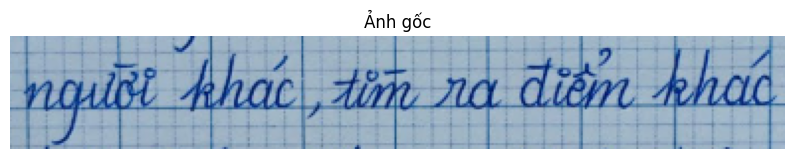

--------------------------------------------------
 Thời gian nhận dạng : 0.76 giây
 KẾT QUẢ ĐỌC ĐƯỢC   : người khác, tìm ra điểm khác
--------------------------------------------------


In [ ]:
import os
import time
import matplotlib.pyplot as plt
from PIL import Image
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg
import torch

if not hasattr(Image, 'ANTIALIAS'):
    Image.ANTIALIAS = getattr(Image, 'Resampling', Image).LANCZOS

try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except:
    pass


weights_path = "/content/drive/MyDrive/Do_An_OCR_VietOCR/final_weights.pth"

if not os.path.exists(weights_path):
    print(f" Không tìm thấy file {weights_path}! Hãy kiểm tra lại tên thư mục trên Drive.")
else:

    print("Đang tải mô hình VietOCR từ Google Drive (chỉ mất vài giây)...")
    config = Cfg.load_config_from_name('vgg_transformer')

    config['device'] = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    print(f"[INFO] Using device: {config['device']}")

    config['weights'] = weights_path
    config['predictor']['beamsearch'] = False # Tắt beamsearch để đọc nhanh hơn

    predictor = Predictor(config)
    print(" Tải mô hình thành công!\n")

    from google.colab import files
    print("=" * 50)
    print("HÃY CHỌN MỘT BỨC ẢNH CHỮ VIẾT TAY ĐỂ TEST")
    print("=" * 50)

    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\n[INFO] Đang xử lý: {filename}")
        image = Image.open(filename).convert("RGB")

        plt.figure(figsize=(10, 4))
        plt.imshow(image)
        plt.axis('off')
        plt.title("Ảnh gốc")
        plt.show()

        start = time.time()
        text = predictor.predict(image)
        end = time.time()

        print("-" * 50)
        print(f" Thời gian nhận dạng : {end - start:.2f} giây")
        print(f" KẾT QUẢ ĐỌC ĐƯỢC   : {text}")
        print("-" * 50)